In [101]:
import importlib
import src.api.option_fetcher as option_fetcher
import src.analysis.volatility_smile as volatility_smile

importlib.reload(option_fetcher)
OptionFetcher = option_fetcher.OptionFetcher

importlib.reload(volatility_smile)
VolatilitySmileAnalyzer = volatility_smile.VolatilitySmileAnalyzer

from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np
from scipy.interpolate import RBFInterpolator
from scipy.signal import savgol_filter

In [102]:
load_dotenv()
api_key = os.getenv("API_KEY")
secret_key = os.getenv("SECRET_KEY")

In [103]:
fetcher = OptionFetcher(api_key, secret_key)

In [104]:
# Build an expiration date rang for the options we will fetch
expiration_dates = fetcher.build_expiration_dates()
expiration_dates

['2026-05-22',
 '2026-05-29',
 '2026-06-05',
 '2026-06-12',
 '2026-06-19',
 '2026-06-26',
 '2026-07-03',
 '2026-07-10',
 '2026-07-17',
 '2026-07-24',
 '2026-07-31',
 '2026-08-28',
 '2026-09-25',
 '2026-10-23',
 '2026-12-25',
 '2027-03-26',
 '2027-06-25',
 '2027-12-24']

In [105]:
# Symbol of the underlying 
ticker = "SPY"
# We will fetch options with a strike price in the range [spot-delta, spot+delta]
spot_delta = 20

In [107]:
#Build the options dataframe, containing for each option the strike, expiry, type etc..
spot_price = fetcher.get_spot_price(ticker)
df = fetcher.build_options_df(ticker,expiration_dates,spot_delta,100)
df.head()

,symbol,strike,expiry,type,bid,ask,mid,spread,timestamp
0,SPY260522C00719000,719.0,2026-05-22,call,21.95,22.25,22.100,0.30,2026-05-15 19:59:59.617408+00:00
1,SPY260522C00720000,720.0,2026-05-22,call,20.81,21.15,20.980,0.34,2026-05-15 19:59:59.211199+00:00
2,SPY260522C00721000,721.0,2026-05-22,call,20.09,20.77,20.430,0.68,2026-05-15 19:59:59.650802+00:00
3,SPY260522C00722000,722.0,2026-05-22,call,19.22,19.86,19.540,0.64,2026-05-15 19:59:59.910392+00:00
4,SPY260522C00723000,723.0,2026-05-22,call,18.25,18.58,18.415,0.33,2026-05-15 19:59:59.704951+00:00


In [108]:
# ToDo add dynamic risk free rate fetching
# Build a dataframe containing the data necessary for smile-plotting : 
# implied_vol, strike, time_to_expiry, moneyness and type
smile = VolatilitySmileAnalyzer(df, spot_price, 0.045)
smile_df = smile.build_smile_data()
smile_df.head()

,implied_vol,strike,expiration_date,time_to_expiry,moneyness,type
0,0.229436,719.0,2026-05-22,0.016485,0.973529,call
1,0.217020,720.0,2026-05-22,0.016485,0.974883,call
2,0.227389,721.0,2026-05-22,0.016485,0.976237,call
3,0.223705,722.0,2026-05-22,0.016485,0.977591,call
4,0.211138,723.0,2026-05-22,0.016485,0.978945,call


In [109]:
# For the smile plot (2D), we select one expiration date
expiry_date = "2026-05-22"
target = pd.to_datetime(expiry_date).date()
smile_data_2d = smile_df[(smile_df["expiration_date"] == target)]
smile_data_2d.head()

,implied_vol,strike,expiration_date,time_to_expiry,moneyness,type
0,0.229436,719.0,2026-05-22,0.016485,0.973529,call
1,0.217020,720.0,2026-05-22,0.016485,0.974883,call
2,0.227389,721.0,2026-05-22,0.016485,0.976237,call
3,0.223705,722.0,2026-05-22,0.016485,0.977591,call
4,0.211138,723.0,2026-05-22,0.016485,0.978945,call


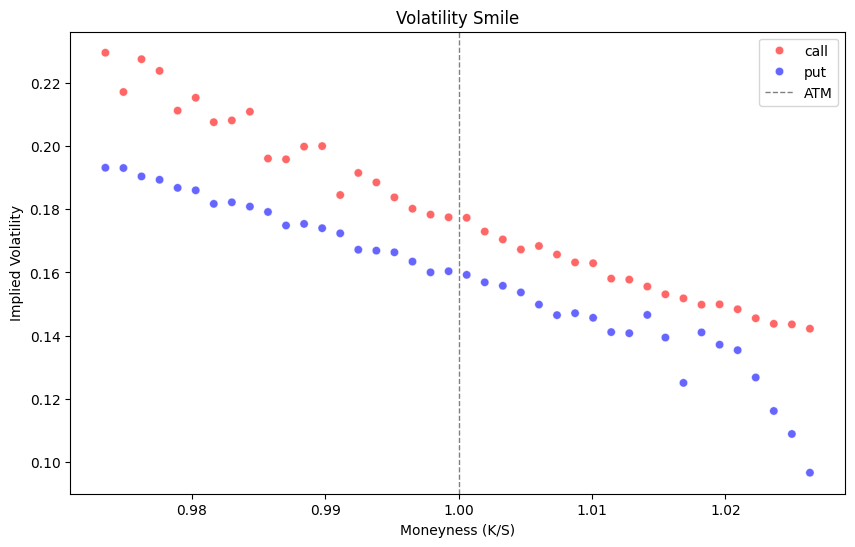

In [110]:
# We then plot IV as a function moneyness (NB : we could also plot IV vs Strike)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=smile_data_2d, x='moneyness', y='implied_vol', hue='type', 
                palette={'put': 'blue', 'call': 'red'}, alpha=0.6)
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1, label='ATM')
plt.xlabel("Moneyness (K/S)")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.legend()
plt.show()

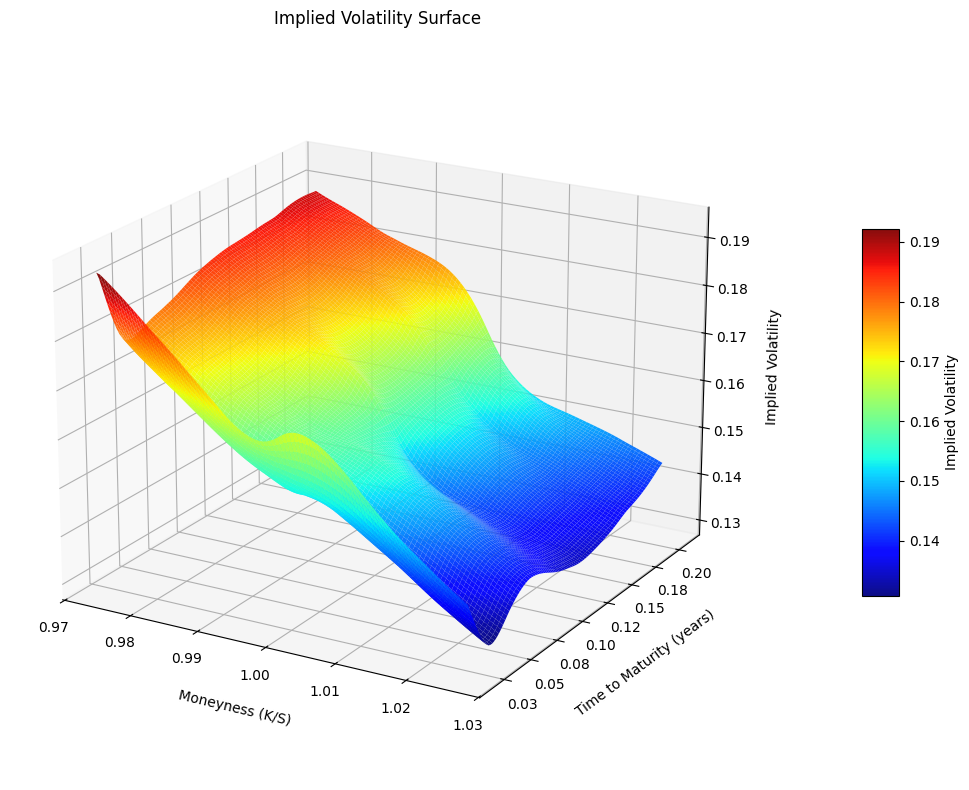

In [111]:
df = smile_df.dropna(subset=['strike', 'implied_vol', 'time_to_expiry', 'moneyness', 'type']).copy()
df['time_to_expiry'] = df['time_to_expiry'].astype(float)

# Put-call parity splitting : puts for K < S (moneyness < 1), calls for K > S (moneyness > 1)
# ATM (moneyness == 1) : we keep calls by default
spot_proxy = df['strike'].iloc[(df['moneyness'] - 1).abs().argsort().iloc[0]]  # strike le plus proche de ATM

df_surface = pd.concat([
    df[(df['type'] == 'put')  & (df['strike'] <  spot_proxy)],
    df[(df['type'] == 'call') & (df['strike'] >= spot_proxy)],
])

# If we want to plot the surface for only call or put, uncomment the 2 lines below
# option_type = "call"
# df_surface = df[df["type"] == option_type]

# Lissage Savitzky-Golay par maturité
df_surface = df_surface.sort_values(['time_to_expiry', 'moneyness'])
smoothed_vols = []
for mat, group in df_surface.groupby('time_to_expiry'):
    group = group.sort_values('moneyness')
    vols = group['implied_vol'].values
    window = min(11, len(vols) if len(vols) % 2 == 1 else len(vols) - 1)
    vols_smooth = savgol_filter(vols, window_length=window, polyorder=3) if window >= 5 else vols
    smoothed_vols.extend(vols_smooth)
df_surface['implied_vol_smooth'] = smoothed_vols

# RBFInterpolator sur moneyness x time_to_expiry
points = df_surface[['moneyness', 'time_to_expiry']].values
values = df_surface['implied_vol_smooth'].values

xi = np.linspace(df_surface['moneyness'].min(), df_surface['moneyness'].max(), 100)
yi = np.linspace(df_surface['time_to_expiry'].min(), df_surface['time_to_expiry'].max(), 100)
Xi, Yi = np.meshgrid(xi, yi)
grid_points = np.column_stack([Xi.ravel(), Yi.ravel()])

rbf = RBFInterpolator(points, values, kernel='thin_plate_spline', smoothing=1e-4)
Zi = rbf(grid_points).reshape(Xi.shape)

vol_min, vol_max = df_surface['implied_vol'].min(), df_surface['implied_vol'].max()
Zi = np.clip(Zi, vol_min, vol_max)

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    Xi, Yi, Zi,
    cmap='jet',
    edgecolor='none',
    antialiased=True,
    rcount=150,
    ccount=150,
    alpha=0.95
)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1, label='Implied Volatility')

zp = 0.05 * (vol_max - vol_min)
ax.set_zlim(max(0.0, vol_min - zp), vol_max + zp)

ax.view_init(elev=20, azim=-60)
ax.set_xlabel('Moneyness (K/S)', labelpad=12)
ax.set_ylabel('Time to Maturity (years)', labelpad=12)
ax.set_zlabel('Implied Volatility', labelpad=10)
ax.set_title('Implied Volatility Surface', pad=15)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()